In [14]:
# Keras 사용 모델 학습 코드

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import ResNet50 # Keras 공식 지원은 ResNet50부터입니다.
from tensorflow.keras.callbacks import EarlyStopping
# ResNet18을 꼭 쓰고 싶다면 분류 라이브러리인 classification_models를 쓰거나 ResNet50을 추천합니다.
import numpy as np
from sklearn.metrics import classification_report

print("🔥 현재 인식된 GPU 목록:", tf.config.list_physical_devices('GPU'))

# =========================================================
# 1. 데이터 전처리 및 로드 (ImageFolder 대신 image_dataset_from_directory)
# =========================================================
img_height, img_width = 256, 256
batch_size = 32

# 데이터셋을 자동으로 Train/Validation으로 나누어 로드합니다.
train_ds = tf.keras.utils.image_dataset_from_directory(
    './my_room_dataset',
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    './my_room_dataset',
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# ResNet 입력 규격에 맞는 전처리 (0~255 -> -1~1 혹은 ResNet 표준화)
normalization_layer = layers.Rescaling(1./255) # 혹은 ResNet50 전용 preprocess_input 사용
train_ds = train_ds.map(lambda x, y: (tf.keras.applications.resnet50.preprocess_input(x), y))
val_ds = val_ds.map(lambda x, y: (tf.keras.applications.resnet50.preprocess_input(x), y))

# ⭐️ 추가/수정된 부분: 흑백 변환 후 3채널 복제 로직을 포함한 전처리 함수 생성
def preprocess_to_grayscale_3ch(image, label):
    # 1. 이미지를 흑백(1채널)으로 변환하여 색상 정보를 제거합니다.
    gray_img = tf.image.rgb_to_grayscale(image)
    
    # 2. ResNet50 규격(3채널)을 맞추기 위해 흑백 채널을 3개로 복제합니다.
    # 이렇게 하면 모양은 3채널이지만, 내용은 완벽한 흑백 이미지가 됩니다.
    gray_3ch_img = tf.image.grayscale_to_rgb(gray_img)
    
    # 3. 기존에 쓰시던 ResNet50 전용 전처리를 적용합니다.
    final_img = tf.keras.applications.resnet50.preprocess_input(gray_3ch_img)
    
    return final_img, label

# 데이터셋에 새로운 전처리 함수를 덮어씌웁니다.
train_ds = train_ds.map(preprocess_to_grayscale_3ch)
val_ds = val_ds.map(preprocess_to_grayscale_3ch)

# =========================================================
# 2. 모델 정의 (ResNet50 전이 학습)
# =========================================================
# Keras 공식 라이브러리는 ResNet18 대신 ResNet50이 기본입니다. (더 깊고 정확함)

# ⭐️ 1. 데이터 증강 레이어 정의 
# (학습할 때마다 이미지를 무작위로 조금씩 변형시킵니다)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"), # 좌우 반전 (방향이 바뀌어도 더러운 건 더러운 것이니까요!)
    layers.RandomRotation(0.1),      # 최대 10% 무작위 회전 (사진이 약간 삐뚤게 찍힌 상황 가정)
    layers.RandomZoom(0.1),          # 최대 10% 무작위 확대/축소 (카메라 거리가 조금 다른 상황 가정)
])

# Keras 공식 라이브러리 ResNet50 불러오기
base_model = tf.keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=(256, 256, 3))

# 베이스 모델 가중치는 고정 (Freezing) - 학습되지 않게 함
base_model.trainable = False 

model = models.Sequential([
    data_augmentation,               # ⭐️ 2. 모델의 맨 첫 번째 관문으로 증강 레이어 삽입!
    base_model,                      # 그 다음 ResNet50을 통과
    layers.GlobalAveragePooling2D(),
    layers.Dense(1, activation='sigmoid') # 이진 분류 (Clean/Dirty)
])

# =========================================================
# 3. 컴파일 및 학습
# =========================================================
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy', # ⭐️ 수정 2: 이진 분류 전용 손실 함수로 변경합니다!
    metrics=['accuracy']
)

# ⭐️ Early Stopping 콜백 정의
early_stopping = EarlyStopping(
    monitor='val_loss',        # 감시할 지표 (검증 세트의 오차)
    patience=3,                # 오차가 줄어들지 않아도 몇 번의 에폭(Epoch)을 더 참을 것인가?
    restore_best_weights=True  # 멈췄을 때, 가장 성능이 좋았던 시점의 가중치로 자동 복구! (매우 중요)
)

print("\n🚀 Keras ResNet 전이 학습을 시작합니다!")
epochs = 200
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=[early_stopping]
)

# =========================================================
# 4. 모델 저장 (keras 형식)
# =========================================================
model.save('resnet_room_clean_model.keras')
print("✨ Keras 모델 학습 및 저장(resnet_room_clean_model.keras) 완료!")

print("\n📊 검증 데이터(Validation)를 바탕으로 정밀 평가를 시작합니다...")

y_true = []
y_pred = []

# ⭐️ 주의: 데이터 순서가 섞이지 않도록(Shuffle 방지) 
# 검증 데이터셋(val_ds)에서 정답과 예측값을 한 번의 반복문에서 동시에 뽑아냅니다.
for images, labels in val_ds:
    # 1. 실제 정답(True Labels) 저장
    y_true.extend(labels.numpy())
    
    # 2. 모델 예측 (0.0 ~ 1.0 사이의 확률값 반환)
    preds = model.predict(images, verbose=0)
    
    # 3. 확률이 0.5보다 크면 1(Dirty), 작거나 같으면 0(Clean)으로 변환
    preds_binary = (preds > 0.5).astype(int).flatten()
    y_pred.extend(preds_binary)

# 4. scikit-learn의 classification_report를 사용하여 4가지 지표 출력
target_names = ['Clean (0)', 'Dirty (1)']
report = classification_report(y_true, y_pred, target_names=target_names)

print("\n=======================================================")
print(report)
print("=======================================================")

🔥 현재 인식된 GPU 목록: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Found 2755 files belonging to 2 classes.
Using 2204 files for training.
Found 2755 files belonging to 2 classes.
Using 551 files for validation.

🚀 Keras ResNet 전이 학습을 시작합니다!
Epoch 1/200
69/69 [==============================] - 16s 170ms/step - loss: 0.6884 - accuracy: 0.5767 - val_loss: 0.5575 - val_accuracy: 0.7568
Epoch 2/200
69/69 [==============================] - 12s 169ms/step - loss: 0.4862 - accuracy: 0.8008 - val_loss: 0.4030 - val_accuracy: 0.8621
Epoch 3/200
69/69 [==============================] - 12s 165ms/step - loss: 0.3896 - accuracy: 0.8589 - val_loss: 0.3269 - val_accuracy: 0.8911
Epoch 4/200
69/69 [==============================] - 12s 164ms/step - loss: 0.3376 - accuracy: 0.8893 - val_loss: 0.2823 - val_accuracy: 0.9111
Epoch 5/200
69/69 [==============================] - 12s 165ms/step - loss: 0.3028 - accuracy: 0.9002 - val_loss: 0.2545 - val_accuracy: 0.9183
Epoch 6/200
69/69 [==

In [ ]:
# Keras 사용 모델 검증 코드 (흑백 3채널 전처리 통합본)

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image

# =========================================================
# 1. 모델 세팅
# =========================================================
model_path = 'resnet_room_clean_model.keras' 
model = tf.keras.models.load_model(model_path)

# 폴더명 알파벳 순서대로 클래스가 매핑됩니다.
classes = ['clean', 'dirty'] 

# =========================================================
# 2. 테스트할 폴더 및 파일 읽기
# =========================================================
test_folder = './test_images' 
image_files = [f for f in os.listdir(test_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

print(f"📂 '{test_folder}' 폴더에서 총 {len(image_files)}장의 이미지를 발견했습니다!\n")
print("=== 🤖 Keras AI 판독 시작 (흑백 필터 적용) ===")

# =========================================================
# 3. 폴더 안의 여러 사진 연속으로 테스트하기
# =========================================================
for file_name in image_files:
    image_path = os.path.join(test_folder, file_name)
    
    try:
        # 1. Keras 내장 함수로 이미지를 부르고 크기를 맞춥니다 (256x256)
        img = image.load_img(image_path, target_size=(256, 256))
        img_array = image.img_to_array(img)
        
        # ⭐️ 2. 학습할 때와 동일하게 흑백 변환 후 3채널 복제 (새로 추가된 부분)
        img_tensor = tf.convert_to_tensor(img_array)
        gray_img = tf.image.rgb_to_grayscale(img_tensor)       # 흑백(1채널)으로 변환
        gray_3ch_img = tf.image.grayscale_to_rgb(gray_img)     # ResNet 규격에 맞춰 3채널로 복제
        
        # 3. 모델은 항상 '배치(묶음)' 단위로 받기 때문에 차원을 하나 추가합니다.
        # (256, 256, 3) ➡️ (1, 256, 256, 3)
        input_tensor = tf.expand_dims(gray_3ch_img, axis=0)
        
        # 4. ResNet50 전처리 방식을 적용
        input_tensor = tf.keras.applications.resnet50.preprocess_input(input_tensor)

        # 5. 모델 예측
        outputs = model.predict(input_tensor, verbose=0)
        
        # 6. 결과 해석 및 확신도(Confidence) 계산 (이진 분류 기준)
        probability = outputs[0][0]
        
        if probability > 0.5:
            result = classes[1] # 'dirty'
            confidence = probability * 100
        else:
            result = classes[0] # 'clean'
            confidence = (1.0 - probability) * 100
            
        print(f"[{file_name}] ➡️ 판독 결과: {result} ({confidence:.1f}% 확신)")
        
    except Exception as e:
        print(f"[{file_name}] ❌ 이미지 처리 중 에러 발생: {e}")

print("\n✨ 모든 사진의 판독이 완료되었습니다!")

In [ ]:
# Keras 기반 ResNet 비지도 학습(클러스터링) 코드

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from sklearn.cluster import KMeans

# =========================================================
# 1. 특징 추출기(Feature Extractor) 모델 세팅
# =========================================================
# 기존에 학습했던 모델을 불러옵니다.
model_path = 'resnet_room_clean_model.keras'
original_model = tf.keras.models.load_model(model_path)

# ⭐️ 핵심: 마지막 분류기 층(Dense)을 제외하고, 특징(숫자 배열)만 뽑아내도록 모델을 재구성합니다.
# original_model.layers[-2]는 GlobalAveragePooling2D 층을 의미합니다.
feature_extractor = tf.keras.Model(
    inputs=original_model.input, 
    outputs=original_model.layers[-2].output
)

# =========================================================
# 2. 이미지 폴더 및 파일 읽기
# =========================================================
unsupervised_folder = './unsupervised'
image_files = [f for f in os.listdir(unsupervised_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

print(f"📂 '{unsupervised_folder}' 폴더에서 총 {len(image_files)}장의 이미지를 발견했습니다!\n")
print("=== 🤖 특징 추출 시작 ===")

features_list = []
valid_image_names = []

# =========================================================
# 3. 모든 이미지의 특징(Feature) 추출하기
# =========================================================
for file_name in image_files:
    image_path = os.path.join(unsupervised_folder, file_name)
    try:
        # 이미지 불러오기 및 크기 맞추기
        img = image.load_img(image_path, target_size=(256, 256))
        img_array = image.img_to_array(img)
        
        # ⭐️ 흑백 변환 후 3채널 복제 (색상 노이즈 제거용 전처리 유지)
        img_tensor = tf.convert_to_tensor(img_array)
        gray_img = tf.image.rgb_to_grayscale(img_tensor)
        gray_3ch_img = tf.image.grayscale_to_rgb(gray_img)
        
        # 차원 추가 및 ResNet 전처리
        input_tensor = tf.expand_dims(gray_3ch_img, axis=0)
        input_tensor = tf.keras.applications.resnet50.preprocess_input(input_tensor)

        # 특징 추출! (확률값이 아니라, 이미지를 요약한 긴 숫자 배열이 나옵니다)
        features = feature_extractor.predict(input_tensor, verbose=0)
        
        # 추출된 특징과 파일명을 각각 저장
        features_list.append(features[0]) 
        valid_image_names.append(file_name) 
        
    except Exception as e:
        print(f"[{file_name}] ❌ 이미지 처리 중 에러 발생: {e}")

# 리스트를 K-Means 알고리즘이 계산하기 좋은 형태로 변환
features_matrix = np.array(features_list)

# =========================================================
# 4. K-Means 클러스터링 (비슷한 방끼리 묶기)
# =========================================================

# n_clusters=2: 일단 두 개의 그룹으로 묶어보라고 지시합니다. (원하시면 3이나 4로 늘려도 됩니다!)
num_clusters = 3
kmeans = KMeans(n_clusters=num_clusters, random_state=42)

print("\n🧠 K-Means 알고리즘이 특징을 바탕으로 그룹을 나누고 있습니다...")
kmeans.fit(features_matrix)

# =========================================================
# 5. 결과 출력
# =========================================================
# 각 이미지가 몇 번 그룹(0 또는 1)에 할당되었는지 확인합니다.
cluster_labels = kmeans.labels_

print("\n✨ 클러스터링 완료! 각 그룹에 배정된 사진들을 확인해 보세요:\n")

for cluster_id in range(num_clusters):
    print(f"=== 🏷️ 그룹 {cluster_id} ===")
    
    # 현재 그룹(cluster_id)에 속한 이미지들의 이름만 추려냅니다.
    cluster_images = [valid_image_names[i] for i, label in enumerate(cluster_labels) if label == cluster_id]
    
    for img_name in cluster_images:
        print(f" - {img_name}")
    print("-" * 30)


📊 데이터 시각화를 준비하고 있습니다...


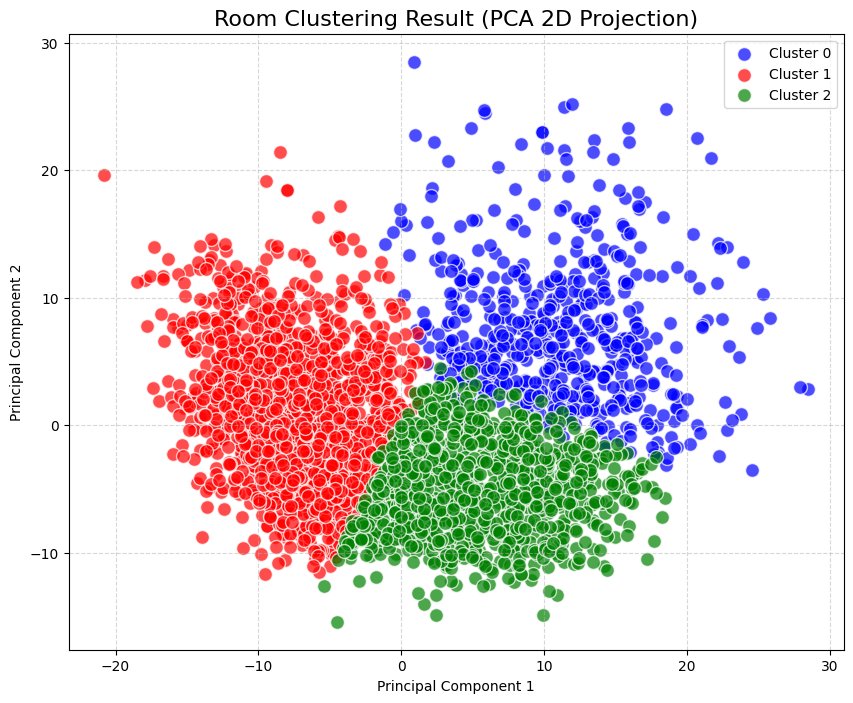


🖼️ 각 군집별 대표 예시 이미지를 출력합니다...


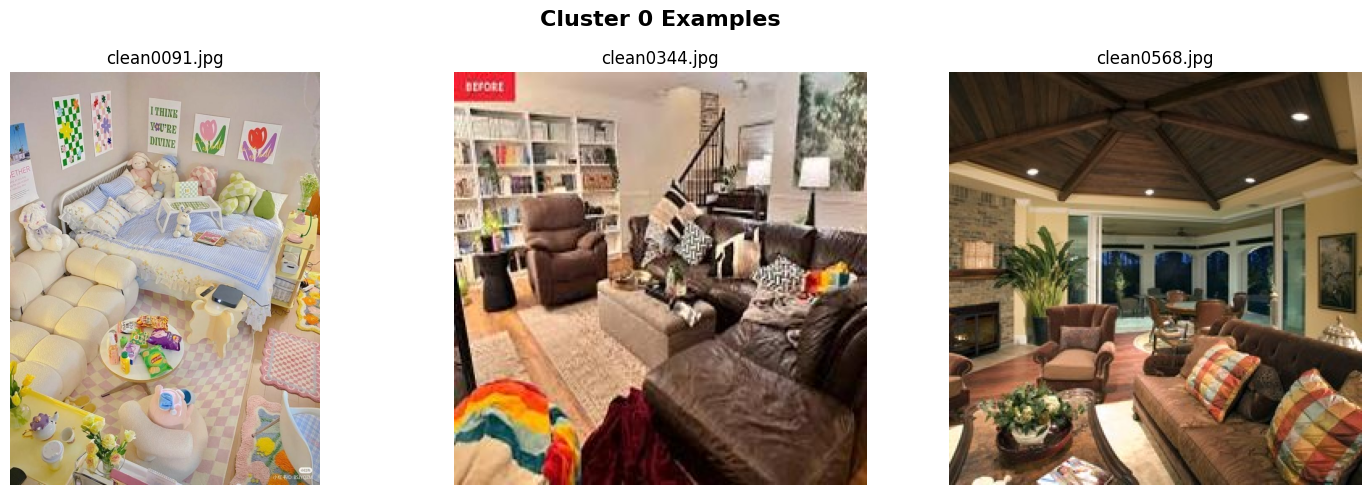

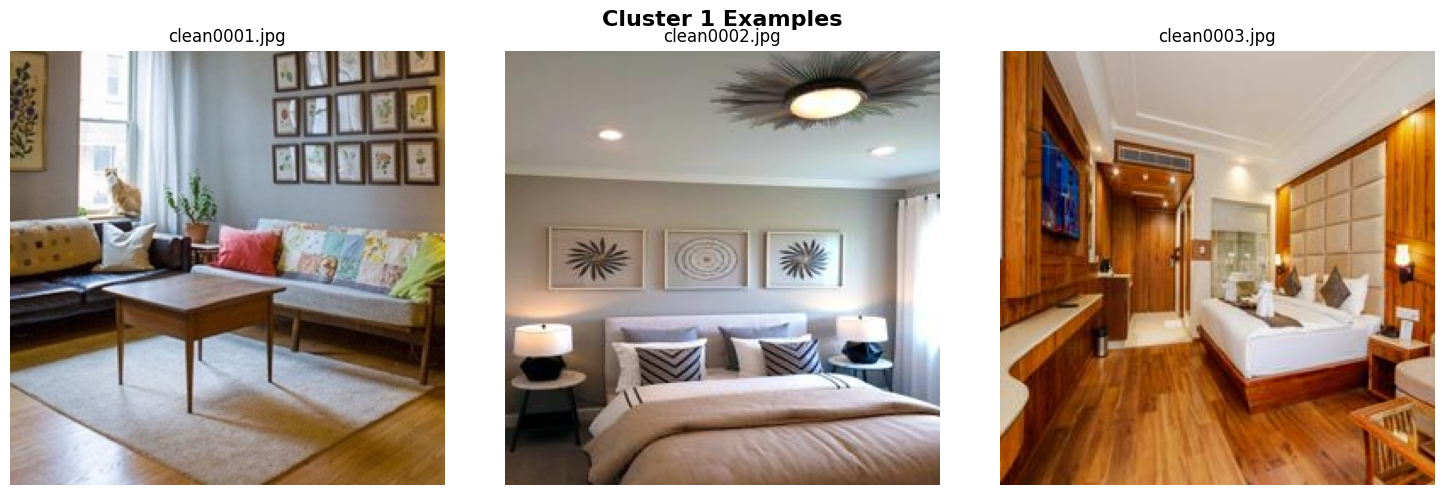

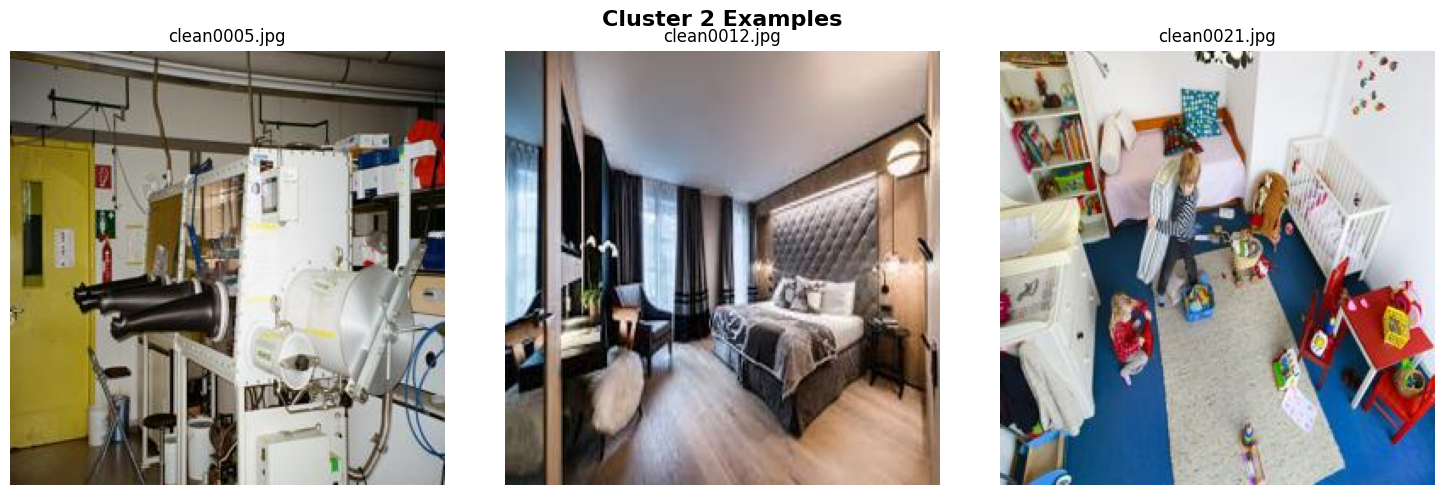


✨ 모든 시각화 작업이 완료되었습니다!


In [8]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

print("\n📊 데이터 시각화를 준비하고 있습니다...")

# 1) 고차원 특징 데이터를 2차원(X, Y)으로 압축 (PCA)
pca = PCA(n_components=2)
features_2d = pca.fit_transform(features_matrix)

# 2) 산포도(Scatter Plot) 그리기
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green', 'purple', 'orange'] # 군집 색상 설정 (최대 5개 군집 대비)

for cluster_id in range(num_clusters):
    # 현재 군집에 속하는 데이터의 인덱스 찾기
    indices = np.where(cluster_labels == cluster_id)[0]
    
    # 해당 군집의 X, Y 좌표 가져오기
    x_coords = features_2d[indices, 0]
    y_coords = features_2d[indices, 1]
    
    # 산포도에 점 찍기
    plt.scatter(x_coords, y_coords, 
                c=colors[cluster_id % len(colors)], 
                label=f'Cluster {cluster_id}', 
                alpha=0.7, edgecolors='w', s=100)

plt.title('Room Clustering Result (PCA 2D Projection)', fontsize=16)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 3) 각 그룹별 예시 이미지 최대 3장씩 출력하기
print("\n🖼️ 각 군집별 대표 예시 이미지를 출력합니다...")

for cluster_id in range(num_clusters):
    # 현재 군집에 속하는 이미지 이름들 가져오기
    cluster_images = [valid_image_names[i] for i, label in enumerate(cluster_labels) if label == cluster_id]
    
    # 보여줄 이미지 개수 설정 (최대 3장, 만약 군집 내 이미지가 3장보다 적으면 그만큼만)
    num_to_show = min(3, len(cluster_images))
    
    if num_to_show == 0:
        continue
        
    plt.figure(figsize=(15, 5))
    plt.suptitle(f'Cluster {cluster_id} Examples', fontsize=16, fontweight='bold')
    
    for i in range(num_to_show):
        img_name = cluster_images[i]
        img_path = os.path.join(unsupervised_folder, img_name)
        
        # 이미지 불러오기
        img = mpimg.imread(img_path)
        
        # 서브플롯(가로로 나란히 배치)에 이미지 그리기
        plt.subplot(1, 3, i + 1)
        plt.imshow(img)
        plt.title(img_name)
        plt.axis('off') # 지저분한 축 눈금 숨기기
        
    plt.tight_layout()
    plt.show()

print("\n✨ 모든 시각화 작업이 완료되었습니다!")

In [9]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.resnet50 import preprocess_input
from ultralytics import YOLO
import numpy as np
import cv2

# ===============================
# 1️⃣ Keras ResNet 모델 로드
# ===============================
model = load_model("resnet_room_clean_model.keras")
print("✅ Keras ResNet 모델 로드 완료")

# ===============================
# 2️⃣ YOLO 모델 로드
# ===============================

yolo_model = YOLO("yolov8n.pt")
print("✅ YOLO 모델 로드 완료")

# ===============================
# 3️⃣ CNN 청결도 점수 계산 (수정됨)
# ===============================
def predict_clean_score(image):
    """
    CNN 모델로 이미지 청결도 예측 (이진 분류 및 흑백 전처리 적용)
    """
    # 1. 256x256 크기 조정
    img = cv2.resize(image, (256, 256))

    # 2. 흑백 3채널 전처리 로직 (색상 노이즈 제거)
    img_tensor = tf.convert_to_tensor(img, dtype=tf.float32)
    gray_img = tf.image.rgb_to_grayscale(img_tensor)
    gray_3ch_img = tf.image.grayscale_to_rgb(gray_img)

    # 3. 차원 추가 및 ResNet 전처리
    input_tensor = tf.expand_dims(gray_3ch_img, axis=0)
    input_tensor = tf.keras.applications.resnet50.preprocess_input(input_tensor)

    # 4. 모델 예측 (Sigmoid 단일 확률값 반환)
    preds = model.predict(input_tensor, verbose=0)
    prob_value = float(preds[0][0]) 

    # 5. 확률 계산
    dirty_prob = prob_value          # 1에 가까울수록 Dirty
    clean_prob = 1.0 - prob_value    # 0에 가까울수록 Clean

    # 6. 상태 판단 (이진 분류: Clean / Dirty)
    if prob_value >= 0.5:
        state = "Dirty"
    else:
        state = "Clean"

    # 7. 청결도 점수 계산 (Clean 확률을 100점 만점으로 환산)
    score = clean_prob * 100

    return score, state, clean_prob, dirty_prob

# ===============================
# 4️⃣ YOLO 객체 분석
# ===============================
def analyze_objects(image_path):
    """
    YOLO로 객체 감지 후 spread, clutter 계산
    """
    results = yolo_model(image_path)
    boxes = results[0].boxes.xyxy.cpu().numpy()
    classes = results[0].boxes.cls.cpu().numpy()
    names = yolo_model.names

    if len(boxes) == 0:
        return 0, 0, 0 # spread, clutter_count, obj_count

    centers = []
    clutter_count = 0

    # 지저분 객체 정의 (필요시 커스터마이징)
    clutter_objects = ["cup", "bottle", "bowl", "book", "cell phone"]

    for box, cls in zip(boxes, classes):
        x1, y1, x2, y2 = box
        cx = (x1 + x2)/2
        cy = (y1 + y2)/2
        centers.append([cx, cy])

        label = names[int(cls)]
        if label in clutter_objects:
            clutter_count += 1

    centers = np.array(centers)
    spread = np.var(centers[:,0]) + np.var(centers[:,1])

    return spread, clutter_count, len(boxes)

# ===============================
# 5️⃣ 객체 배치 점수 계산
# ===============================
def arrangement_score(spread):
    score = 100 - spread * 0.0005
    score = max(0, min(score, 100))
    return score

# ===============================
# 6️⃣ Clutter 패널티
# ===============================
def clutter_penalty(clutter_count):
    penalty = clutter_count * 5
    penalty = min(penalty, 30)
    return penalty

# ===============================
# 7️⃣ 최종 청결도 계산
# ===============================
def final_score(image_path):
    # 이미지 로드 + RGB 변환 (OpenCV는 기본이 BGR이므로 RGB 변환 필수)
    image = cv2.imread(image_path)
    if image is None:
        print(f"❌ '{image_path}' 이미지를 불러올 수 없습니다. 경로를 확인해주세요.")
        return

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # CNN 청결도 (수정된 함수 사용)
    clean_score, state, clean_prob, dirty_prob = predict_clean_score(image)

    # YOLO 분석
    spread, clutter_count, obj_count = analyze_objects(image_path)
    arr_score = arrangement_score(spread)
    penalty = clutter_penalty(clutter_count)

    # 앙상블 계산
    final = 0.7 * clean_score + 0.3 * arr_score - penalty
    final = max(0, min(final, 100))

    # 결과 출력
    print("\n===== 분석 결과 =====")
    print(f"CNN 청결도 점수: {round(clean_score, 2)} / 100")
    print(f"Clean 확률: {round(clean_prob, 3)} | Dirty 확률: {round(dirty_prob, 3)}")
    print(f"CNN 판독 상태: {state}")
    print("-" * 21)
    print(f"감지된 전체 객체 수: {obj_count}개")
    print(f"객체 흩어짐(Spread) 정도: {round(spread, 2)}")
    print(f"객체 배치 점수: {round(arr_score, 2)} / 100")
    print(f"어지름 유발 객체(Clutter) 수: {clutter_count}개")
    print(f"어지름 패널티: -{penalty}점")
    print("=" * 21)
    print(f"✨ 앙상블 최종 청결도 점수: {round(final, 2)} / 100")

# ===============================
# 8️⃣ 실행
# ===============================
image_path = "test2.jpg"
final_score(image_path)

✅ Keras ResNet 모델 로드 완료
✅ YOLO 모델 로드 완료

image 1/1 c:\Users\kccistc\Desktop\DeepLearning_Project\test2.jpg: 640x640 (no detections), 7.7ms
Speed: 4.3ms preprocess, 7.7ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)

===== 분석 결과 =====
CNN 청결도 점수: 90.2 / 100
Clean 확률: 0.902 | Dirty 확률: 0.098
CNN 판독 상태: Clean
---------------------
감지된 전체 객체 수: 0개
객체 흩어짐(Spread) 정도: 0
객체 배치 점수: 100.0 / 100
어지름 유발 객체(Clutter) 수: 0개
어지름 패널티: -0점
✨ 앙상블 최종 청결도 점수: 93.14 / 100


In [14]:
# Kaggle 외부 모델(.h5) 2단계 평가 코드

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.xception import preprocess_input, Xception

# =========================================================
# 1. 두 개의 모델 세팅 (몸통 + 머리)
# =========================================================
# 1) 원작자의 머리(분류기) 로드
model_path = 'room_model.h5' # 👈 다운로드한 파일명을 정확히 적어주세요!
head_model = tf.keras.models.load_model(model_path)

print(f"✅ 원작자 분류기 모델 로드 완료! (입력 규격: {head_model.input_shape})")

# 2) Xception의 눈(특징 추출 몸통) 로드
# 원작자가 썼던 것과 동일하게 ImageNet 가중치를 가진 Xception을 부릅니다.
# include_top=False로 기존 머리를 떼어내고, pooling='avg'로 사진을 1차원 숫자로 요약합니다.
base_model = Xception(weights='imagenet', include_top=False, pooling='avg', input_shape=(256, 256, 3))
print("✅ Xception 특징 추출기 로드 완료!")

# =========================================================
# 2. 테스트할 폴더 및 파일 읽기
# =========================================================
test_folder = './test_images' 
image_files = [f for f in os.listdir(test_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

print(f"\n📂 '{test_folder}' 폴더에서 총 {len(image_files)}장의 이미지를 평가합니다.")
print("=== 🤖 2단계 릴레이 AI 판독 시작 ===")

for file_name in image_files:
    image_path = os.path.join(test_folder, file_name)
    
    try:
        # 1. 이미지 로드 (Xception 기본 규격인 299x299로 고정)
        img = image.load_img(image_path, target_size=(256, 256))
        img_array = image.img_to_array(img)
        input_tensor = np.expand_dims(img_array, axis=0)
        
        # 2. Xception 전용 전처리
        input_tensor = preprocess_input(input_tensor)

        # ⭐️ 3. 핵심! 2단계 릴레이 예측
        # 1단계: 몸통을 통과시켜 특징(1차원 숫자 배열) 추출
        features = base_model.predict(input_tensor, verbose=0)
        
        # 2단계: 추출된 특징을 원작자의 머리 모델에 넣어서 최종 판단
        outputs = head_model.predict(features, verbose=0)
        
        # 4. 결과 해석 
        if head_model.output_shape[-1] == 1: # 이진 분류 (Sigmoid)
            prob = outputs[0][0]
            result = "Dirty" if prob > 0.5 else "Clean"
            confidence = prob * 100 if prob > 0.5 else (1 - prob) * 100
        else: # 다중 분류 (Softmax)
            predicted_index = np.argmax(outputs[0])
            result = "Clean" if predicted_index == 0 else "Dirty" 
            confidence = outputs[0][predicted_index] * 100

        print(f"[{file_name}] ➡️ 판독 결과: {result} ({confidence:.1f}% 확신)")
        
    except Exception as e:
        print(f"[{file_name}] ❌ 이미지 처리 중 에러 발생: {e}")

print("\n✨ 모든 사진의 평가가 완료되었습니다!")

✅ 원작자 분류기 모델 로드 완료! (입력 규격: (None, 2048))
✅ Xception 특징 추출기 로드 완료!

📂 './test_images' 폴더에서 총 472장의 이미지를 평가합니다.
=== 🤖 2단계 릴레이 AI 판독 시작 ===
[normal0002.jpg] ➡️ 판독 결과: Clean (79.3% 확신)
[normal0003.jpg] ➡️ 판독 결과: Clean (55.3% 확신)
[normal0011.jpg] ➡️ 판독 결과: Dirty (64.1% 확신)
[normal0023.jpg] ➡️ 판독 결과: Clean (54.2% 확신)
[normal0024.jpg] ➡️ 판독 결과: Clean (80.4% 확신)
[normal0026.jpg] ➡️ 판독 결과: Dirty (81.9% 확신)
[normal0030.jpg] ➡️ 판독 결과: Clean (91.6% 확신)
[normal0031.jpg] ➡️ 판독 결과: Dirty (67.1% 확신)
[normal0032.jpg] ➡️ 판독 결과: Dirty (84.2% 확신)
[normal0033.jpg] ➡️ 판독 결과: Clean (73.7% 확신)
[normal0034.jpg] ➡️ 판독 결과: Dirty (60.5% 확신)
[normal0035.jpg] ➡️ 판독 결과: Clean (58.2% 확신)
[normal0036.jpg] ➡️ 판독 결과: Dirty (93.9% 확신)
[normal0042.jpg] ➡️ 판독 결과: Clean (54.1% 확신)
[normal0043.jpg] ➡️ 판독 결과: Dirty (90.1% 확신)
[normal0044.jpg] ➡️ 판독 결과: Clean (56.6% 확신)
[normal0045.jpg] ➡️ 판독 결과: Clean (78.6% 확신)
[normal0049.jpg] ➡️ 판독 결과: Dirty (82.3% 확신)
[normal0053.jpg] ➡️ 판독 결과: Clean (90.3% 확신)
[normal0074.jpg] ➡️ 판독 결과:

In [ ]:
# Keras 사용 컬러 Xception 모델 학습 코드 (데이터 증강 O, 흑백 변환 X)

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications.xception import Xception, preprocess_input
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
from sklearn.metrics import classification_report

print("🔥 현재 인식된 GPU 목록:", tf.config.list_physical_devices('GPU'))

# =========================================================
# 1. 데이터 전처리 및 로드
# =========================================================
# ⭐️ 수정 1: Xception의 기본 권장 해상도인 299x299로 변경!
img_height, img_width = 299, 299
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    './my_room_dataset',
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    './my_room_dataset',
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# ⭐️ 수정 2: 흑백 변환을 빼고, 오직 Xception 전용 스케일링(-1 ~ 1)만 적용합니다.
train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))

# =========================================================
# 2. 모델 정의 (데이터 증강 + 컬러 Xception)
# =========================================================
# 데이터 증강 (컬러 이미지의 방향, 각도, 크기만 무작위로 변형)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# 베이스 모델: Xception (299x299 컬러 규격)
base_model = Xception(weights='imagenet', include_top=False, input_shape=(299, 299, 3))
base_model.trainable = False # 가중치 고정

model = models.Sequential([
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(1, activation='sigmoid') # Clean / Dirty 이진 분류
])

# =========================================================
# 3. 컴파일 및 학습
# =========================================================
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy', 
    metrics=['accuracy']
)

# Early Stopping (과적합 방지)
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

print("\n🚀 컬러 Xception 전이 학습을 시작합니다!")
epochs = 200
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=[early_stopping]
)

# =========================================================
# 4. 모델 저장 (.keras 형식)
# =========================================================
model.save('color_xception_room_model.keras')
print("✨ 컬러 Xception 모델 학습 및 저장(color_xception_room_model.keras) 완료!")

# =========================================================
# 5. 정밀 평가 (검증 데이터)
# =========================================================
print("\n📊 검증 데이터(Validation)를 바탕으로 정밀 평가를 시작합니다...")

y_true = []
y_pred = []

for images, labels in val_ds:
    y_true.extend(labels.numpy())
    preds = model.predict(images, verbose=0)
    preds_binary = (preds > 0.5).astype(int).flatten()
    y_pred.extend(preds_binary)

target_names = ['Clean (0)', 'Dirty (1)']
report = classification_report(y_true, y_pred, target_names=target_names)

print("\n=======================================================")
print(report)
print("=======================================================")

In [13]:
# Keras 사용 컬러 Xception 모델 검증 코드

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.xception import preprocess_input # ⭐️ Xception 전용 전처리

# =========================================================
# 1. 모델 세팅
# =========================================================
# 방금 새롭게 학습시킨 컬러 Xception 모델의 이름을 적어주세요.
model_path = 'color_xception_room_model.keras' 
model = tf.keras.models.load_model(model_path)

# 폴더명 알파벳 순서대로 클래스가 매핑됩니다. (c가 먼저니까 clean이 0, dirty가 1)
classes = ['clean', 'dirty'] 

# =========================================================
# 2. 테스트할 폴더 및 파일 읽기
# =========================================================
test_folder = './test_images' 
image_files = [f for f in os.listdir(test_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

print(f"📂 '{test_folder}' 폴더에서 총 {len(image_files)}장의 이미지를 발견했습니다!\n")
print("=== 🤖 컬러 Xception AI 판독 시작 ===")

# =========================================================
# 3. 폴더 안의 여러 사진 연속으로 테스트하기
# =========================================================
for file_name in image_files:
    image_path = os.path.join(test_folder, file_name)
    
    try:
        # ⭐️ 1. Xception 규격에 맞게 299x299 크기로 이미지를 부릅니다 (컬러 원본 유지)
        img = image.load_img(image_path, target_size=(299, 299))
        img_array = image.img_to_array(img)
        
        # 2. 모델은 항상 '배치(묶음)' 단위로 받기 때문에 차원을 하나 추가합니다.
        input_tensor = np.expand_dims(img_array, axis=0)
        
        # ⭐️ 3. 학습할 때 썼던 Xception 전용 전처리 방식을 똑같이 적용! (흑백 변환 없음)
        input_tensor = preprocess_input(input_tensor)

        # 4. 모델 예측
        outputs = model.predict(input_tensor, verbose=0)
        
        # 5. 결과 해석 및 확신도(Confidence) 계산 (Sigmoid 기준)
        probability = outputs[0][0]
        
        # 0.5를 기준으로 Clean(0)과 Dirty(1)을 나눕니다.
        if probability > 0.5:
            result = classes[1] # 'dirty'
            confidence = probability * 100
        else:
            result = classes[0] # 'clean'
            confidence = (1.0 - probability) * 100
            
        # 보기 좋게 한 줄씩 결과 출력
        print(f"[{file_name}] ➡️ 판독 결과: {result} ({confidence:.1f}% 확신)")
        
    except Exception as e:
        print(f"[{file_name}] ❌ 이미지 처리 중 에러 발생: {e}")

print("\n✨ 모든 사진의 판독이 완료되었습니다!")

📂 './test_images' 폴더에서 총 472장의 이미지를 발견했습니다!

=== 🤖 컬러 Xception AI 판독 시작 ===
[normal0002.jpg] ➡️ 판독 결과: clean (86.0% 확신)
[normal0003.jpg] ➡️ 판독 결과: clean (84.3% 확신)
[normal0011.jpg] ➡️ 판독 결과: clean (86.8% 확신)
[normal0023.jpg] ➡️ 판독 결과: clean (61.1% 확신)
[normal0024.jpg] ➡️ 판독 결과: clean (93.2% 확신)
[normal0026.jpg] ➡️ 판독 결과: clean (52.2% 확신)
[normal0030.jpg] ➡️ 판독 결과: clean (91.6% 확신)
[normal0031.jpg] ➡️ 판독 결과: dirty (68.7% 확신)
[normal0032.jpg] ➡️ 판독 결과: dirty (89.0% 확신)
[normal0033.jpg] ➡️ 판독 결과: clean (91.8% 확신)
[normal0034.jpg] ➡️ 판독 결과: clean (70.2% 확신)
[normal0035.jpg] ➡️ 판독 결과: dirty (82.0% 확신)
[normal0036.jpg] ➡️ 판독 결과: dirty (88.6% 확신)
[normal0042.jpg] ➡️ 판독 결과: dirty (72.0% 확신)
[normal0043.jpg] ➡️ 판독 결과: dirty (96.0% 확신)
[normal0044.jpg] ➡️ 판독 결과: dirty (61.5% 확신)
[normal0045.jpg] ➡️ 판독 결과: dirty (52.4% 확신)
[normal0049.jpg] ➡️ 판독 결과: dirty (69.1% 확신)
[normal0053.jpg] ➡️ 판독 결과: clean (92.1% 확신)
[normal0074.jpg] ➡️ 판독 결과: dirty (67.3% 확신)
[normal0087.jpg] ➡️ 판독 결과: dirty (84.5% 확신)
